=== 三维角点网格角点坐标 ===
网格维度: 3 x 3 x 2 个角点
对应 2 x 2 x 1 个网格单元

角点坐标 (i, j, k): (X, Y, Z)
(0, 0, 0): (1.000, 0.000, 0.000)
(0, 0, 1): (0.000, 0.777, 6.000)
(0, 1, 0): (0.839, 2.000, 0.072)
(0, 1, 1): (-0.619, 2.768, 5.979)
(0, 2, 0): (0.608, 8.000, -0.107)
(0, 2, 1): (-0.448, 8.772, 6.094)
(1, 0, 0): (7.000, 0.000, 0.798)
(1, 0, 1): (5.000, 0.245, 6.796)
(1, 1, 0): (5.839, 4.000, 0.285)
(1, 1, 1): (4.381, 4.356, 6.202)
(1, 2, 0): (6.608, 8.000, -0.586)
(1, 2, 1): (4.552, 8.326, 5.374)
(2, 0, 0): (11.000, 0.000, 0.113)
(2, 0, 1): (10.000, -1.622, 6.111)
(2, 1, 0): (10.839, 2.600, -0.032)
(2, 1, 1): (9.381, 1.957, 6.131)
(2, 2, 0): (10.608, 8.000, 0.024)
(2, 2, 1): (9.552, 7.434, 5.866)

总计: 18 个角点
计算得到的4个点的坐标:
p[0]: [2.930071, 1.768135, 3.266566]
p[1]: [7.930071, 1.441851, 3.300477]
p[2]: [2.719982, 5.777640, 2.914082]
p[3]: [7.719982, 5.583953, 2.907996]
1.1479716067981456
1.6907865554222983
0.7212640064250375


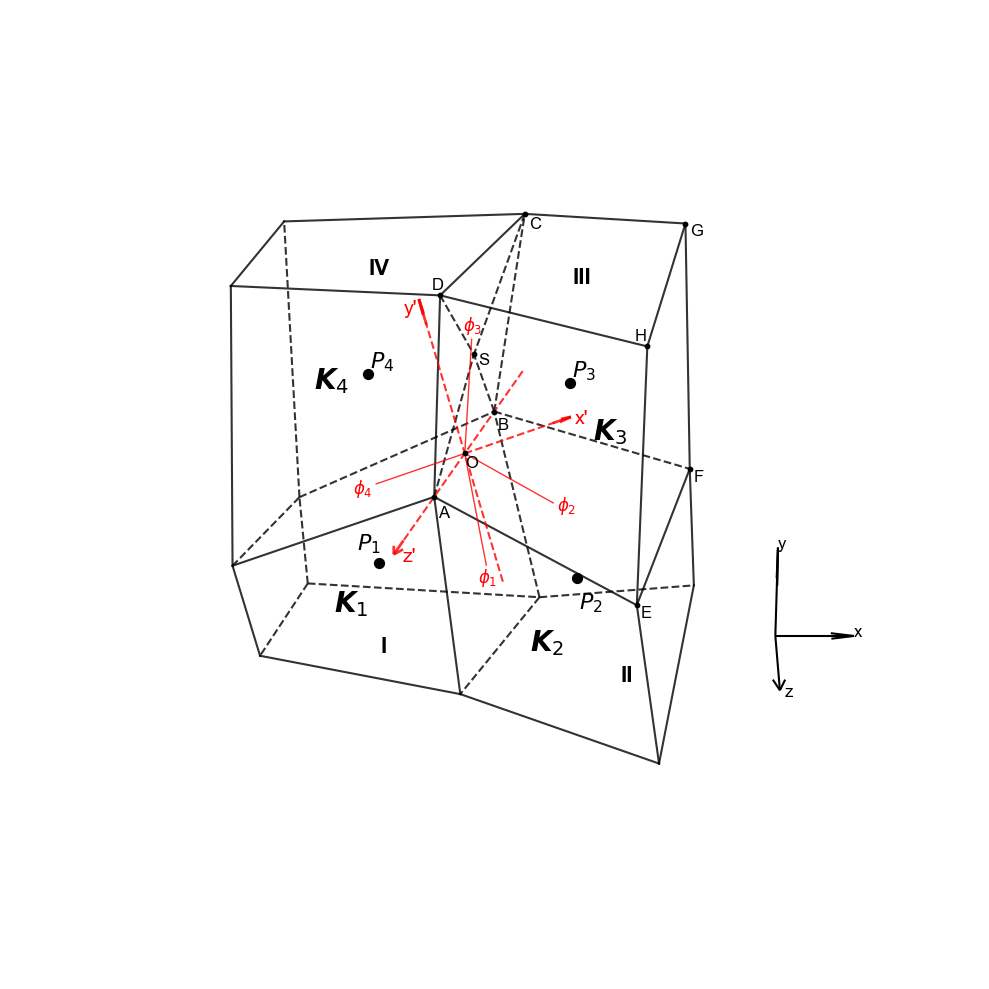

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def angle_between_3d(A, B):
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)

    normA = np.linalg.norm(A)
    normB = np.linalg.norm(B)
    if normA == 0 or normB == 0:
        raise ValueError("零向量没有定义夹角")

    cos_theta = np.dot(A, B) / (normA * normB)
    cos_theta = np.clip(cos_theta, -1.0, 1.0)  # 防浮点误差
    theta = np.arccos(cos_theta)               # 弧度

    return theta


# 设置matplotlib使用英文/ASCII字体（移除中文字体支持）
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 1. 定义网格维度（Ni, Nj, Nk 为角点数量）
ni, nj, nk = 3, 3, 2

# 2. 创建初始规则的角点坐标
x = np.linspace(0, 10, ni)
y = np.linspace(0, 8, nj)
z = np.linspace(0, 6, nk)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# 3. 调整扭曲效果，保持适度
# 对X方向添加适度的扭曲：随y和z变化，减小幅度
X += 0.9 * np.sin(Y * 0.3) * np.cos(Z * 0.4)

# 对Y方向添加适度的扭曲：随x和z变化
Y += 0.9 * np.cos(X * 0.25) * np.sin(Z * 0.35)

# 对Z方向保持适度的扭曲
Z += 0.8 * np.sin(X * 0.3) * np.cos(Y * 0.3)
X[0,0,0] += 1.0
X[1,0,0] += 2.0
X[2,0,0] += 1.0
X[1,2,0] += 1.0
Y[2,1,0] -= 1.4
Y[2,1,1] -= 1.5
Y[2,0,1]-=1
Y[0,1,0]-=2.0
Y[0,1,1]-=2.0

# 4. 打印每个角点的坐标值
print("=== 三维角点网格角点坐标 ===")
print(f"网格维度: {ni} x {nj} x {nk} 个角点")
print(f"对应 {ni-1} x {nj-1} x {nk-1} 个网格单元")
print("\n角点坐标 (i, j, k): (X, Y, Z)")

corner_count = 0
for i in range(ni):
    for j in range(nj):
        for k in range(nk):
            print(f"({i}, {j}, {k}): ({X[i, j, k]:.3f}, {Y[i, j, k]:.3f}, {Z[i, j, k]:.3f})")
            corner_count += 1

print(f"\n总计: {corner_count} 个角点")

# 4. 可视化：绘制所有角点和连接线
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# 添加坐标轴指示器
ax.quiver(13, 0, 3, 2, 0, 0, color='k', arrow_length_ratio=0.3)
ax.quiver(13, 0, 3, 0, 2, 0, color='k', arrow_length_ratio=0.4)
ax.quiver(13, 0, 3, 0, 0, 3, color='k', arrow_length_ratio=0.2)

# 设置标签
ax.text(15, 0, 3, 'x', color='k', fontsize=12)
ax.text(13, 2, 3, 'y', color='k', fontsize=12)
ax.text(13.1, 0, 6.3, 'z', color='k', fontsize=12)

# 设置视角
ax.view_init(elev=120, azim=-90)

# 5. 完全展开所有循环，每条线单独绘制

# i方向的线 - 共12条
# j=0, k=0 的2条线
ax.plot([X[0, 0, 0], X[1, 0, 0]], [Y[0, 0, 0], Y[1, 0, 0]], [Z[0, 0, 0], Z[1, 0, 0]], 'k--', alpha=0.8, linewidth=1.5)
ax.plot([X[1, 0, 0], X[2, 0, 0]], [Y[1, 0, 0], Y[2, 0, 0]], [Z[1, 0, 0], Z[2, 0, 0]], 'k--', alpha=0.8, linewidth=1.5)

# j=1, k=0 的2条线
ax.plot([X[0, 1, 0], X[1, 1, 0]], [Y[0, 1, 0], Y[1, 1, 0]], [Z[0, 1, 0], Z[1, 1, 0]], 'k--', alpha=0.8, linewidth=1.5)
ax.plot([X[1, 1, 0], X[2, 1, 0]], [Y[1, 1, 0], Y[2, 1, 0]], [Z[1, 1, 0], Z[2, 1, 0]], 'k--', alpha=0.8, linewidth=1.5)

# j=2, k=0 的2条线
ax.plot([X[0, 2, 0], X[1, 2, 0]], [Y[0, 2, 0], Y[1, 2, 0]], [Z[0, 2, 0], Z[1, 2, 0]], 'k-', alpha=0.8, linewidth=1.5)
ax.plot([X[1, 2, 0], X[2, 2, 0]], [Y[1, 2, 0], Y[2, 2, 0]], [Z[1, 2, 0], Z[2, 2, 0]], 'k-', alpha=0.8, linewidth=1.5)

# j=0, k=1 的2条线
ax.plot([X[0, 0, 1], X[1, 0, 1]], [Y[0, 0, 1], Y[1, 0, 1]], [Z[0, 0, 1], Z[1, 0, 1]], 'k-', alpha=0.8, linewidth=1.5)
ax.plot([X[1, 0, 1], X[2, 0, 1]], [Y[1, 0, 1], Y[2, 0, 1]], [Z[1, 0, 1], Z[2, 0, 1]], 'k-', alpha=0.8, linewidth=1.5)

# j=1, k=1 的2条线
ax.plot([X[0, 1, 1], X[1, 1, 1]], [Y[0, 1, 1], Y[1, 1, 1]], [Z[0, 1, 1], Z[1, 1, 1]], 'k-', alpha=0.8, linewidth=1.5)
ax.plot([X[1, 1, 1], X[2, 1, 1]], [Y[1, 1, 1], Y[2, 1, 1]], [Z[1, 1, 1], Z[2, 1, 1]], 'k-', alpha=0.8, linewidth=1.5)

# j=2, k=1 的2条线
ax.plot([X[0, 2, 1], X[1, 2, 1]], [Y[0, 2, 1], Y[1, 2, 1]], [Z[0, 2, 1], Z[1, 2, 1]], 'k-', alpha=0.8, linewidth=1.5)
ax.plot([X[1, 2, 1], X[2, 2, 1]], [Y[1, 2, 1], Y[2, 2, 1]], [Z[1, 2, 1], Z[2, 2, 1]], 'k-', alpha=0.8, linewidth=1.5)

# j方向的线 - 共12条
# i=0, k=0 的2条线
ax.plot([X[0, 0, 0], X[0, 1, 0]], [Y[0, 0, 0], Y[0, 1, 0]], [Z[0, 0, 0], Z[0, 1, 0]], 'k--', alpha=0.8, linewidth=1.5)
ax.plot([X[0, 1, 0], X[0, 2, 0]], [Y[0, 1, 0], Y[0, 2, 0]], [Z[0, 1, 0], Z[0, 2, 0]], 'k--', alpha=0.8, linewidth=1.5)

# i=1, k=0 的2条线
ax.plot([X[1, 0, 0], X[1, 1, 0]], [Y[1, 0, 0], Y[1, 1, 0]], [Z[1, 0, 0], Z[1, 1, 0]], 'k--', alpha=0.8, linewidth=1.5)
ax.plot([X[1, 1, 0], X[1, 2, 0]], [Y[1, 1, 0], Y[1, 2, 0]], [Z[1, 1, 0], Z[1, 2, 0]], 'k--', alpha=0.8, linewidth=1.5)

# i=2, k=0 的2条线
ax.plot([X[2, 0, 0], X[2, 1, 0]], [Y[2, 0, 0], Y[2, 1, 0]], [Z[2, 0, 0], Z[2, 1, 0]], 'k-', alpha=0.8, linewidth=1.5)
ax.plot([X[2, 1, 0], X[2, 2, 0]], [Y[2, 1, 0], Y[2, 2, 0]], [Z[2, 1, 0], Z[2, 2, 0]], 'k-', alpha=0.8, linewidth=1.5)

# i=0, k=1 的2条线
ax.plot([X[0, 0, 1], X[0, 1, 1]], [Y[0, 0, 1], Y[0, 1, 1]], [Z[0, 0, 1], Z[0, 1, 1]], 'k-', alpha=0.8, linewidth=1.5)
ax.plot([X[0, 1, 1], X[0, 2, 1]], [Y[0, 1, 1], Y[0, 2, 1]], [Z[0, 1, 1], Z[0, 2, 1]], 'k-', alpha=0.8, linewidth=1.5)

# i=1, k=1 的2条线
ax.plot([X[1, 0, 1], X[1, 1, 1]], [Y[1, 0, 1], Y[1, 1, 1]], [Z[1, 0, 1], Z[1, 1, 1]], 'k-', alpha=0.8, linewidth=1.5)
ax.plot([X[1, 1, 1], X[1, 2, 1]], [Y[1, 1, 1], Y[1, 2, 1]], [Z[1, 1, 1], Z[1, 2, 1]], 'k-', alpha=0.8, linewidth=1.5)

# i=2, k=1 的2条线
ax.plot([X[2, 0, 1], X[2, 1, 1]], [Y[2, 0, 1], Y[2, 1, 1]], [Z[2, 0, 1], Z[2, 1, 1]], 'k-', alpha=0.8, linewidth=1.5)
ax.plot([X[2, 1, 1], X[2, 2, 1]], [Y[2, 1, 1], Y[2, 2, 1]], [Z[2, 1, 1], Z[2, 2, 1]], 'k-', alpha=0.8, linewidth=1.5)

# k方向的线 - 共9条
# i=0, j=0
ax.plot([X[0, 0, 0], X[0, 0, 1]], [Y[0, 0, 0], Y[0, 0, 1]], [Z[0, 0, 0], Z[0, 0, 1]], 'k--', alpha=0.8, linewidth=1.5)

# i=0, j=1
ax.plot([X[0, 1, 0], X[0, 1, 1]], [Y[0, 1, 0], Y[0, 1, 1]], [Z[0, 1, 0], Z[0, 1, 1]], 'k--', alpha=0.8, linewidth=1.5)

# i=0, j=2
ax.plot([X[0, 2, 0], X[0, 2, 1]], [Y[0, 2, 0], Y[0, 2, 1]], [Z[0, 2, 0], Z[0, 2, 1]], 'k-', alpha=0.8, linewidth=1.5)

# i=1, j=0
ax.plot([X[1, 0, 0], X[1, 0, 1]], [Y[1, 0, 0], Y[1, 0, 1]], [Z[1, 0, 0], Z[1, 0, 1]], 'k--', alpha=0.8, linewidth=1.5)

# i=1, j=1
#ax.plot([X[1, 1, 0], X[1, 1, 1]], [Y[1, 1, 0], Y[1, 1, 1]], [Z[1, 1, 0], Z[1, 1, 1]], 'k-', alpha=0.8, linewidth=1.5)

# i=1, j=2
ax.plot([X[1, 2, 0], X[1, 2, 1]], [Y[1, 2, 0], Y[1, 2, 1]], [Z[1, 2, 0], Z[1, 2, 1]], 'k-', alpha=0.8, linewidth=1.5)

# i=2, j=0
ax.plot([X[2, 0, 0], X[2, 0, 1]], [Y[2, 0, 0], Y[2, 0, 1]], [Z[2, 0, 0], Z[2, 0, 1]], 'k-', alpha=0.8, linewidth=1.5)

# i=2, j=1
ax.plot([X[2, 1, 0], X[2, 1, 1]], [Y[2, 1, 0], Y[2, 1, 1]], [Z[2, 1, 0], Z[2, 1, 1]], 'k-', alpha=0.8, linewidth=1.5)

# i=2, j=2
ax.plot([X[2, 2, 0], X[2, 2, 1]], [Y[2, 2, 0], Y[2, 2, 1]], [Z[2, 2, 0], Z[2, 2, 1]], 'k-', alpha=0.8, linewidth=1.5)

# 获取点A (1,1,1) 和点B (1,1,0) 的坐标
x_A, y_A, z_A = X[1, 1, 1], Y[1, 1, 1], Z[1, 1, 1]
x_B, y_B, z_B = X[1, 1, 0], Y[1, 1, 0], Z[1, 1, 0]
x_c,y_c,z_c=X[1, 2, 0], Y[1, 2, 0], Z[1, 2, 0]
x_d,y_d,z_d=X[1, 2, 1], Y[1, 2, 1], Z[1, 2, 1]
x_e, y_e, z_e = X[2, 1, 1], Y[2, 1, 1], Z[2, 1, 1]
x_f, y_f, z_f = X[2, 1, 0], Y[2, 1, 0], Z[2, 1, 0]
x_g, y_g, z_g = X[2, 2, 0], Y[2, 2, 0], Z[2, 2, 0]
x_h, y_h, z_h = X[2, 2, 1], Y[2, 2, 1], Z[2, 2, 1]
x_S=(x_A+x_B+x_c+x_d)/4.0
y_S=(y_A+y_B+y_c+y_d)/4.0
z_S=(z_A+z_B+z_c+z_d)/4.0
import numpy as np

# 假设X, Y, Z已经定义，形状为(3, 3, 2)

# 初始化一个4x3的数组，对应p[4][3]
p = np.zeros((4, 3), dtype=float)

# 外层循环：i和j
for i in range(2):  # i从0到1
    for j in range(2):  # j从0到1
        # 计算数组索引：i + 2*j
        idx = i + 2 * j
        
        # 内层循环：l, m, n
        for l in range(2):  # l从0到1
            for m in range(2):  # m从0到1
                for n in range(2):  # n从0到1
                    # 累加坐标
                    p[idx, 0] += X[i + l, j + m, n]
                    p[idx, 1] += Y[i + l, j + m, n]
                    p[idx, 2] += Z[i + l, j + m, n]
        
        # 计算平均值（除以8.0）
        p[idx, 0] /= 8.0
        p[idx, 1] /= 8.0
        p[idx, 2] /= 8.0

# 打印结果
print("计算得到的4个点的坐标:")
for i in range(4):
    print(f"p[{i}]: [{p[i, 0]:.6f}, {p[i, 1]:.6f}, {p[i, 2]:.6f}]")
ax.plot([x_B, x_S],  # x坐标列表
        [y_B, y_S],  # y坐标列表
        [z_B, z_S],  # z坐标列表
        'k--',                        # 颜色和线型
        alpha=0.8, linewidth=1.5)
ax.plot([x_A, x_S],  # x坐标列表
        [y_A, y_S],  # y坐标列表
        [z_A, z_S],  # z坐标列表
        'k--',                        # 颜色和线型
        alpha=0.8, linewidth=1.5)

ax.plot([x_c, x_S],  # x坐标列表
        [y_c, y_S],  # y坐标列表
        [z_c, z_S],  # z坐标列表
        'k--',                        # 颜色和线型
        alpha=0.8, linewidth=1.5)

ax.plot([x_d, x_S],  # x坐标列表
        [y_d, y_S],  # y坐标列表
        [z_d, z_S],  # z坐标列表
        'k--',                        # 颜色和线型
        alpha=0.8, linewidth=1.5)

# 在点上绘制标记点（用不同颜色和大小的点）
ax.scatter(x_A, y_A, z_A, c='k', s=10, label='Point A (1,1,1)')
ax.scatter(x_B, y_B, z_B, c='k', s=10, label='Point B (1,1,0)')
ax.scatter(x_c, y_c, z_c, c='k', s=10, label='Point c (1,2,0)')
ax.scatter(x_d, y_d, z_d, c='k', s=10, label='Point d (1,2,1)')
ax.scatter(x_e, y_e, z_e, c='k', s=10, label='Point d (1,2,1)')
ax.scatter(x_f, y_f, z_f, c='k', s=10, label='Point d (1,2,1)')
ax.scatter(x_g, y_g, z_g, c='k', s=10, label='Point d (1,2,1)')
ax.scatter(x_h, y_h, z_h, c='k', s=10, label='Point d (1,2,1)')
ax.scatter(p[0,0], p[0,1], p[0,2], c='k', s=50, label='Point A (1,1,1)')
ax.scatter(x_S, y_S, z_S, c='k', s=10, label='Point S')
ax.scatter(p[1,0], p[1,1], p[1,2], c='k', s=50, label='Point A (1,1,1)')
ax.scatter(p[3,0], p[3,1], p[3,2], c='k', s=50, label='Point A (1,1,1)')
ax.scatter(p[2,0], p[2,1], p[2,2], c='k', s=50, label='Point A (1,1,1)')
# 添加文字标签，稍微偏移一点避免重叠
ax.text(x_A+0.1 , y_A-0.32, z_A + 0.3, 'A', color='k', fontsize=12)
ax.text(x_B + 0.1, y_B-0.5 , z_B - 0.3, 'B', color='k', fontsize=12)
ax.text(x_c + 0.1, y_c-0.3 , z_c , 'C', color='k', fontsize=12)
ax.text(x_d - 0.2, y_d+0.13 , z_d , 'D', color='k', fontsize=12)
ax.text(x_S + 0.1, y_S-0.2 , z_S , 'S', color='k', fontsize=12)
ax.text(x_e+0.1 , y_e-0.15, z_e + 0.3, 'E', color='k', fontsize=12)
ax.text(x_f+0.1 , y_f-0.15, z_f + 0.3, 'F', color='k', fontsize=12)
ax.text(x_g+0.1 , y_g-0.15, z_g + 0.3, 'G', color='k', fontsize=12)
ax.text(x_h - 0.3, y_h+0.13 , z_h , 'H', color='k', fontsize=12)
ax.text(p[0,0]-0.55, p[0,1]+0.3, p[0,2] , '$P_{1}$', color='k', fontsize=16)
ax.text(p[0,0]-1.1, p[0,1]-0.5, p[0,2] +1.5, r'$\boldsymbol{K}_1$', fontsize=20, color='black')
ax.text(p[1,0]+0.05, p[1,1]-0.7, p[1,2] , '$P_{2}$', color='k', fontsize=16)
ax.text(p[1,0]-1.2, p[1,1]-0.7, p[1,2]+2.3 , r'$\boldsymbol{K}_2$', color='k', fontsize=20)
ax.text(p[3,0]+0.05, p[3,1]+0.15, p[3,2] , '$P_{3}$', color='k', fontsize=16)
ax.text(p[3,0]+0.55, p[3,1]+-0.1, p[3,2]+3.0 , r'$\boldsymbol{K}_3$', color='k', fontsize=20)
ax.text(p[2,0]+0.05, p[2,1]+0.15, p[2,2] , '$P_{4}$', color='k', fontsize=16)
ax.text(p[2,0]-1.35, p[2,1]-0.3, p[2,2] , r'$\boldsymbol{K}_4$', color='k', fontsize=20)
ax.text(p[0,0]+0.05, p[0,1]-1.2, p[0,2] +2.0, 'I', fontsize=16, color='k',fontweight='bold')
ax.text(p[1,0]+1.05, p[1,1]-0.7, p[1,2]+4.0 , 'II', color='k', fontsize=16,fontweight='bold')
ax.text(p[3,0]+0.05, p[3,1]+2.15, p[3,2] , 'III', color='k', fontsize=16,fontweight='bold')
ax.text(p[2,0]+0.05, p[2,1]+2.15, p[2,2] , 'IV', color='k', fontsize=16,fontweight='bold')
# 计算中点O的坐标
x_O = (x_A + x_B) / 2
y_O = (y_A + y_B) / 2
z_O = (z_A + z_B) / 2

# 在点上绘制标记点O
ax.scatter(x_O, y_O, z_O, c='k', s=10, label='Point O (Midpoint)')

# 添加文字标签
ax.text(x_O , y_O-0.3 , z_O , 'O', color='k', fontsize=12)

# 计算AB方向向量（从B到A）
dx = x_A - x_B
dy = y_A - y_B
dz = z_A - z_B
ax.plot([x_B-0.5*dx, x_B+1.5*dx],  # x坐标列表
        [y_B-0.5*dy, y_B+1.5*dy],  # y坐标列表
        [z_B-0.5*dz, z_B+1.5*dz],  # z坐标列表
        'r--',                        # 颜色和线型
        alpha=0.8, linewidth=1.5)

# 在点绘制箭头头（表示正方向）
#ax.scatter(x_A+0.5*dx, y_A+0.5*dy, z_A+0.5*dz, c='red', marker='^', s=20)

ax.text(x_A+0.5*dx, y_A+0.5*dy-0.4 , z_A+0.5*dz , 
        "z'", color='red', fontsize=14)

length = np.sqrt(dx**2 + dy**2 + dz**2)

if length > 0:
    # 单位化
    u_dx = dx / length
    u_dy = dy / length
    u_dz = dz / length
    
    # 在A点绘制一个短箭头，表示方向
    # 箭头长度设为总长度的20%
    arrow_len = length * 0.15

     # 从A点向后退一点开始绘制
    start_x = x_A+0.5*dx - arrow_len * u_dx * 0.1  # 后退10%的箭头长度
    start_y = y_A+0.5*dy - arrow_len * u_dy * 0.1
    start_z = z_A+0.5*dz - arrow_len * u_dz * 0.1
    
    # 绘制箭头
    ax.quiver(start_x, start_y, start_z,
              arrow_len * u_dx, arrow_len * u_dy, arrow_len * u_dz,
              color='red', arrow_length_ratio=0.5, linewidth=2, alpha=0.8)

A = np.array([X[1, 1, 1], Y[1, 1, 1], Z[1, 1, 1]])
B = np.array([X[1, 1, 0], Y[1, 1, 0], Z[1, 1, 0]])
S= np.array([x_S,y_S,z_S])


# 1. 计算AB中点O
O = (A + B) / 2

# 2. 计算AB向量
AB = B - A

point_1_0_0 = np.array([X[1, 1, 0], Y[1, 1, 0], Z[1, 1, 0]])
point_1_1_0 = np.array([X[0, 1, 0], Y[0, 1, 0], Z[0, 1, 0]])
point_1_0_1 = np.array([X[1, 1, 1], Y[1, 1, 1], Z[1, 1, 1]])
point_1_1_1 = np.array([X[0, 1, 1], Y[0, 1, 1], Z[0, 1, 1]])
S4 = (point_1_0_0 + point_1_1_0 + point_1_0_1 + point_1_1_1) / 4
AS4 = S4 - A
normal = np.cross(AB, AS4)

#绘制Y'轴
ax.plot([x_O-0.18*normal[0], x_O+0.18*normal[0]],  # x坐标列表
        [y_O-0.18*normal[1], y_O+0.18*normal[1]],  # y坐标列表
        [z_O-0.18*normal[2], z_O+0.18*normal[2]],  # z坐标列表
        'r--',                        # 颜色和线型
        alpha=0.8, linewidth=1.5)

length = np.sqrt(normal[0]**2 + normal[1]**2 + normal[2]**2)

if length > 0:
    # 单位化
    u_dx = normal[0] / length
    u_dy = normal[1] / length
    u_dz = normal[2] / length
    
    # 在A点绘制一个短箭头，表示方向
    # 箭头长度设为总长度的20%
    arrow_len = length * 0.035

     # 从A点向后退一点开始绘制
    start_x = x_O+0.18*normal[0] - arrow_len * u_dx * 0.1  # 后退10%的箭头长度
    start_y = y_O+0.18*normal[1] - arrow_len * u_dy * 0.1
    start_z = z_O+0.18*normal[2] - arrow_len * u_dz * 0.1
    
    # 绘制箭头
    ax.quiver(start_x, start_y, start_z,
              arrow_len * u_dx, arrow_len * u_dy, arrow_len * u_dz,
              color='red', arrow_length_ratio=0.6, linewidth=2, alpha=0.8)
ax.text(x_O+0.18*normal[0]-0.55, y_O+0.18*normal[1]+0.2 , z_O+0.18*normal[2]  , 
        "y'", color='red', fontsize=14)
perpendicular_pi = np.cross(AB, normal)
if np.linalg.norm(perpendicular_pi) > 0:
    perpendicular_unit = perpendicular_pi / np.linalg.norm(perpendicular_pi)
else:
    # 如果垂直向量为零向量，说明AB与AS平行，需要选择另一个点
    # 这里使用BS向量作为替代
    BS = S4 - B
    normal = np.cross(AB, BS)
    perpendicular = np.cross(AB, normal)
    perpendicular_unit = perpendicular / np.linalg.norm(perpendicular)

# 7. 设置垂线的长度（可以设置为AB长度的一半）
line_length = np.linalg.norm(AB) / 2

# 8. 计算垂线的两个端点
P1 = O
P2 = O -0.8* line_length * perpendicular_unit

# 9. 在图上绘制这条垂线
ax.plot([P1[0], P2[0]], [P1[1], P2[1]], [P1[2], P2[2]], 
        'r', linewidth=1, alpha=0.8, label='Perpendicular to AB in plane ABS')
ax.text(P2[0]-0.58, P2[1]-0.2, P2[2], r'$\phi_{4}$', color='red', fontsize=12)
P2=O +0.8* line_length * perpendicular_unit
#绘制x'轴
ax.plot([O[0], P2[0]],  # x坐标列表
        [O[1], P2[1]],  # y坐标列表
        [O[2], P2[2]],  # z坐标列表
        'r--',                        # 颜色和线型
        alpha=0.8, linewidth=1.5)
normal=P2-O
length = np.sqrt(normal[0]**2 + normal[1]**2 + normal[2]**2)

if length > 0:
    # 单位化
    u_dx = normal[0] / length
    u_dy = normal[1] / length
    u_dz = normal[2] / length
    
    # 在A点绘制一个短箭头，表示方向
    # 箭头长度设为总长度的20%
    arrow_len = length * 0.2

     # 从A点向后退一点开始绘制
    start_x = P2[0] - arrow_len * u_dx * 0.1  # 后退10%的箭头长度
    start_y = P2[1] - arrow_len * u_dy * 0.1
    start_z = P2[2] - arrow_len * u_dz * 0.1
    
    # 绘制箭头
    ax.quiver(start_x, start_y, start_z,
              arrow_len * u_dx, arrow_len * u_dy, arrow_len * u_dz,
              color='red', arrow_length_ratio=0.6, linewidth=2, alpha=0.8)
ax.text(P2[0]+0.5, P2[1] , P2[2]  , 
        "x'", color='red', fontsize=14)

# 3. 计算平面ABS内的向量AS
AS = S - A

# 4. 计算平面ABS的法向量 (AB × AS)
normal = np.cross(AB, AS)

# 5. 在平面ABS内，垂直于AB的向量 (AB × 法向量)
perpendicular = np.cross(AB, normal)
phi_3=angle_between_3d(perpendicular,perpendicular_pi)
print(np.pi-phi_3)
# 6. 归一化垂直向量
if np.linalg.norm(perpendicular) > 0:
    perpendicular_unit = perpendicular / np.linalg.norm(perpendicular)
else:
    # 如果垂直向量为零向量，说明AB与AS平行，需要选择另一个点
    # 这里使用BS向量作为替代
    BS = S - B
    normal = np.cross(AB, BS)
    perpendicular = np.cross(AB, normal)
    perpendicular_unit = perpendicular / np.linalg.norm(perpendicular)

# 7. 设置垂线的长度（可以设置为AB长度的一半）
line_length = np.linalg.norm(AB) / 2

# 8. 计算垂线的两个端点
P1 = O
P2 = O -0.8* line_length * perpendicular_unit

# 9. 在图上绘制这条垂线
ax.plot([P1[0], P2[0]], [P1[1], P2[1]], [P1[2], P2[2]], 
        'r', linewidth=1, alpha=0.8, label='Perpendicular to AB in plane ABS')

# 10. 可选：标注垂线的端点
#ax.scatter(P1[0], P1[1], P1[2], c='green', s=10, marker='o')
#ax.scatter(P2[0], P2[1], P2[2], c='green', s=10)

# 11. 可选：在垂线中点添加标签
ax.text(P2[0]-0.2, P2[1]+0.2, P2[2], r'$\phi_{3}$', color='red', fontsize=12)

point_1_0_0 = np.array([X[1, 0, 0], Y[1, 0, 0], Z[1, 0, 0]])
point_1_1_0 = np.array([X[1, 1, 0], Y[1, 1, 0], Z[1, 1, 0]])
point_1_0_1 = np.array([X[1, 0, 1], Y[1, 0, 1], Z[1, 0, 1]])
point_1_1_1 = np.array([X[1, 1, 1], Y[1, 1, 1], Z[1, 1, 1]])
S1 = (point_1_0_0 + point_1_1_0 + point_1_0_1 + point_1_1_1) / 4
AS1 = S1 - A
normal = np.cross(AB, AS1)


# 在点绘制箭头头（表示正方向）
#ax.scatter(x_A+0.5*dx, y_A+0.5*dy, z_A+0.5*dz, c='red', marker='^', s=20)
perpendicular = np.cross(AB, normal)
perpendicular = np.cross(AB, normal)
phi_1=angle_between_3d(perpendicular,perpendicular_pi)
print(np.pi-phi_1)
if np.linalg.norm(perpendicular) > 0:
    perpendicular_unit = perpendicular / np.linalg.norm(perpendicular)
else:
    # 如果垂直向量为零向量，说明AB与AS平行，需要选择另一个点
    # 这里使用BS向量作为替代
    BS = S1 - B
    normal = np.cross(AB, BS)
    perpendicular = np.cross(AB, normal)
    perpendicular_unit = perpendicular / np.linalg.norm(perpendicular)

# 7. 设置垂线的长度（可以设置为AB长度的一半）
line_length = np.linalg.norm(AB) / 2

# 8. 计算垂线的两个端点
P1 = O
P2 = O -0.8* line_length * perpendicular_unit

# 9. 在图上绘制这条垂线
ax.plot([P1[0], P2[0]], [P1[1], P2[1]], [P1[2], P2[2]], 
        'r', linewidth=1, alpha=0.8, label='Perpendicular to AB in plane ABS')
ax.text(P2[0]-0.2, P2[1]-0.37, P2[2], r'$\phi_{1}$', color='red', fontsize=12)

point_1_0_0 = np.array([X[2, 1, 0], Y[2, 1, 0], Z[2, 1, 0]])
point_1_1_0 = np.array([X[1, 1, 0], Y[1, 1, 0], Z[1, 1, 0]])
point_1_0_1 = np.array([X[2, 1, 1], Y[2, 1, 1], Z[2, 1, 1]])
point_1_1_1 = np.array([X[1, 1, 1], Y[1, 1, 1], Z[1, 1, 1]])
S2 = (point_1_0_0 + point_1_1_0 + point_1_0_1 + point_1_1_1) / 4
AS2 = S2 - A
normal = np.cross(AB, AS2)


# 在点绘制箭头头（表示正方向）
#ax.scatter(x_A+0.5*dx, y_A+0.5*dy, z_A+0.5*dz, c='red', marker='^', s=20)
perpendicular = np.cross(AB, normal)
phi_2=angle_between_3d(perpendicular,perpendicular_pi)
print(np.pi-phi_2)
if np.linalg.norm(perpendicular) > 0:
    perpendicular_unit = perpendicular / np.linalg.norm(perpendicular)
else:
    # 如果垂直向量为零向量，说明AB与AS平行，需要选择另一个点
    # 这里使用BS向量作为替代
    BS = S2 - B
    normal = np.cross(AB, BS)
    perpendicular = np.cross(AB, normal)
    perpendicular_unit = perpendicular / np.linalg.norm(perpendicular)

# 7. 设置垂线的长度（可以设置为AB长度的一半）
line_length = np.linalg.norm(AB) / 2

# 8. 计算垂线的两个端点
P1 = O
P2 = O -0.8* line_length * perpendicular_unit

# 9. 在图上绘制这条垂线
ax.plot([P1[0], P2[0]], [P1[1], P2[1]], [P1[2], P2[2]], 
        'r', linewidth=1, alpha=0.8, label='Perpendicular to AB in plane ABS')
ax.text(P2[0]+0.1, P2[1]-0.15, P2[2], r'$\phi_{2}$', color='red', fontsize=12)

# 使用英文标签
ax.set_xlabel('X (i direction)')
ax.set_ylabel('Y (j direction)')
ax.set_zlabel('Z (k direction)')
ax.set_axis_off()
plt.tight_layout()
plt.show()

C:\Users\31717\AppData\Local\Temp\ipykernel_24464\3735929772.py:64: UserWarning: Glyph 36724 (\N{CJK UNIFIED IDEOGRAPH-8F74}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\31717\AppData\Local\Temp\ipykernel_24464\3735929772.py:64: UserWarning: Glyph 20845 (\N{CJK UNIFIED IDEOGRAPH-516D}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\31717\AppData\Local\Temp\ipykernel_24464\3735929772.py:64: UserWarning: Glyph 38754 (\N{CJK UNIFIED IDEOGRAPH-9762}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\31717\AppData\Local\Temp\ipykernel_24464\3735929772.py:64: UserWarning: Glyph 20307 (\N{CJK UNIFIED IDEOGRAPH-4F53}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\31717\AppData\Local\Temp\ipykernel_24464\3735929772.py:64: UserWarning: Glyph 32593 (\N{CJK UNIFIED IDEOGRAPH-7F51}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\31717\AppData\Local\Temp\ipykernel_24464\3735929772.py:64: UserWarning: Glyph 26684 (\N{CJK UNIFIED IDEOGRAPH-683C})

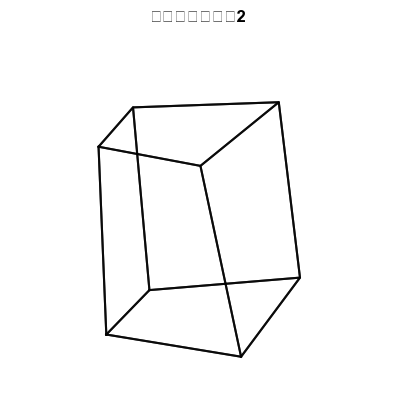

六面体顶点坐标表:
索引		坐标(x, y, z)
----------------------------------------
(0,0,0)	(1.000, 0.000, 0.000)
(0,0,1)	(0.000, 0.777, 6.000)
(0,1,0)	(0.839, 2.000, 0.072)
(0,1,1)	(-0.619, 2.768, 5.979)
(1,0,0)	(7.000, 0.000, 0.798)
(1,0,1)	(5.000, 0.245, 6.796)
(1,1,0)	(5.839, 4.000, 0.285)
(1,1,1)	(4.381, 4.356, 6.202)

六面体尺寸:
X方向: 7.619
Y方向: 4.356
Z方向: 6.796


In [15]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# 顶点坐标数据
vertices = {
    (0, 0, 0): (1.000, 0.000, 0.000),
    (0, 0, 1): (0.000, 0.777, 6.000),
    (0, 1, 0): (0.839, 2.000, 0.072),
    (0, 1, 1): (-0.619, 2.768, 5.979),
    (1, 0, 0): (7.000, 0.000, 0.798),
    (1, 0, 1): (5.000, 0.245, 6.796),
    (1, 1, 0): (5.839, 4.000, 0.285),
    (1, 1, 1): (4.381, 4.356, 6.202)
}

# 六面体的面定义（使用顶点索引）
faces = [
    [(0, 0, 0), (0, 1, 0), (1, 1, 0), (1, 0, 0)],  # 底面 (k=0)
    [(0, 0, 1), (1, 0, 1), (1, 1, 1), (0, 1, 1)],  # 顶面 (k=1)
    [(0, 0, 0), (0, 0, 1), (0, 1, 1), (0, 1, 0)],  # 侧面 (i=0)
    [(1, 0, 0), (1, 1, 0), (1, 1, 1), (1, 0, 1)],  # 侧面 (i=1)
    [(0, 0, 0), (1, 0, 0), (1, 0, 1), (0, 0, 1)],  # 侧面 (j=0)
    [(0, 1, 0), (0, 1, 1), (1, 1, 1), (1, 1, 0)]   # 侧面 (j=1)
]

# 创建图形
fig = plt.figure(figsize=(8, 8))

# 3D视图
ax2 = fig.add_subplot(122, projection='3d')

# 提取所有顶点坐标
all_vertices = list(vertices.values())

# 绘制线框网格
for face in faces:
    # 获取面的顶点坐标
    face_vertices = [vertices[v] for v in face]
    x = [v[0] for v in face_vertices]
    y = [v[1] for v in face_vertices]
    z = [v[2] for v in face_vertices]
    
    # 绘制线框
    x.append(x[0])  # 闭合多边形
    y.append(y[0])
    z.append(z[0])
    
    ax2.plot(x, y, z, 'k-', linewidth=1.5, alpha=0.8)


ax2.set_axis_off()
# 设置ax2的视角（不同的角度）
#ax2.view_init(elev=100, azim=30)
ax2.set_xlabel('X轴')
ax2.set_ylabel('Y轴')
ax2.set_zlabel('Z轴')
ax2.set_title('六面体网格视图2', fontsize=12, fontweight='bold')
# 调整坐标轴比例，使图形更清晰
for ax in [ax1, ax2]:
    ax.set_box_aspect([1, 1, 1])  # 保持3D坐标轴比例一致
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 打印顶点信息
print("六面体顶点坐标表:")
print("索引\t\t坐标(x, y, z)")
print("-" * 40)
for idx, (coords, (x, y, z)) in enumerate(vertices.items()):
    i, j, k = coords
    print(f"({i},{j},{k})\t({x:.3f}, {y:.3f}, {z:.3f})")

# 计算六面体的尺寸
x_coords = [v[0] for v in all_vertices]
y_coords = [v[1] for v in all_vertices]
z_coords = [v[2] for v in all_vertices]

x_range = max(x_coords) - min(x_coords)
y_range = max(y_coords) - min(y_coords)
z_range = max(z_coords) - min(z_coords)

print(f"\n六面体尺寸:")
print(f"X方向: {x_range:.3f}")
print(f"Y方向: {y_range:.3f}")
print(f"Z方向: {z_range:.3f}")

C:\Users\31717\AppData\Local\Temp\ipykernel_24464\476070.py:116: UserWarning: Glyph 36724 (\N{CJK UNIFIED IDEOGRAPH-8F74}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\31717\AppData\Local\Temp\ipykernel_24464\476070.py:116: UserWarning: Glyph 20845 (\N{CJK UNIFIED IDEOGRAPH-516D}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\31717\AppData\Local\Temp\ipykernel_24464\476070.py:116: UserWarning: Glyph 38754 (\N{CJK UNIFIED IDEOGRAPH-9762}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\31717\AppData\Local\Temp\ipykernel_24464\476070.py:116: UserWarning: Glyph 20307 (\N{CJK UNIFIED IDEOGRAPH-4F53}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\31717\AppData\Local\Temp\ipykernel_24464\476070.py:116: UserWarning: Glyph 32454 (\N{CJK UNIFIED IDEOGRAPH-7EC6}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\31717\AppData\Local\Temp\ipykernel_24464\476070.py:116: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font

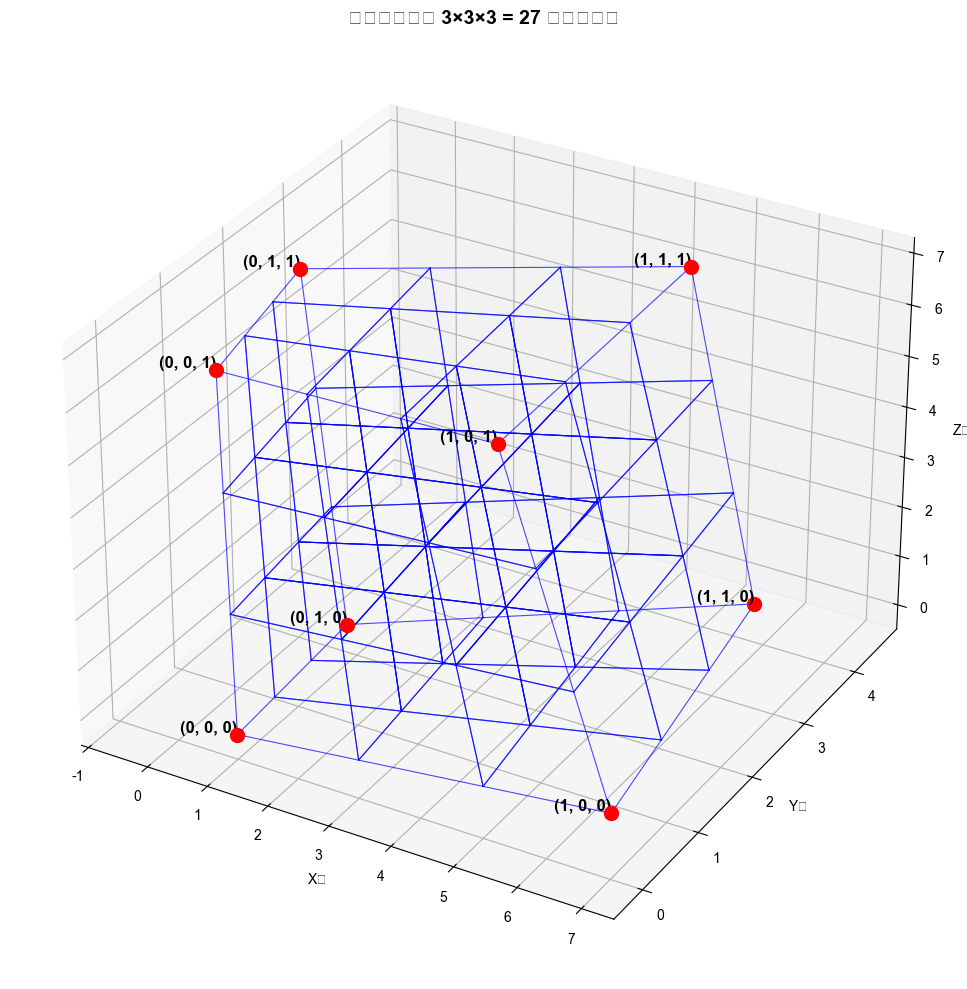

原始六面体已细分为 3×3×3 = 27 个子六面体
细分后共有 64 个网格点
每个方向上的网格点数: u方向=4, v方向=4, w方向=4

细分点坐标示例 (前10个):
点 0: (1.000, 0.000, 0.000)
点 1: (0.667, 0.259, 2.000)
点 2: (0.333, 0.518, 4.000)
点 3: (0.000, 0.777, 6.000)
点 4: (0.946, 0.667, 0.024)
点 5: (0.562, 0.925, 2.014)
点 6: (0.178, 1.183, 4.003)
点 7: (-0.206, 1.441, 5.993)
点 8: (0.893, 1.333, 0.048)
点 9: (0.458, 1.590, 2.027)


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection

def trilinear_interpolation(p000, p001, p010, p011, p100, p101, p110, p111, u, v, w):
    """三线性插值"""
    return (1-u)*(1-v)*(1-w)*p000 + (1-u)*(1-v)*w*p001 + \
           (1-u)*v*(1-w)*p010 + (1-u)*v*w*p011 + \
           u*(1-v)*(1-w)*p100 + u*(1-v)*w*p101 + \
           u*v*(1-w)*p110 + u*v*w*p111

# 原始六面体顶点坐标
vertices = {
    (0, 0, 0): np.array([1.000, 0.000, 0.000]),
    (0, 0, 1): np.array([0.000, 0.777, 6.000]),
    (0, 1, 0): np.array([0.839, 2.000, 0.072]),
    (0, 1, 1): np.array([-0.619, 2.768, 5.979]),
    (1, 0, 0): np.array([7.000, 0.000, 0.798]),
    (1, 0, 1): np.array([5.000, 0.245, 6.796]),
    (1, 1, 0): np.array([5.839, 4.000, 0.285]),
    (1, 1, 1): np.array([4.381, 4.356, 6.202])
}

# 细分参数
n_u, n_v, n_w = 3, 3, 3  # 每个方向细分为3份
num_points_u, num_points_v, num_points_w = n_u + 1, n_v + 1, n_w + 1  # 每个方向4个点

# 生成细分后的所有点
all_points = []
point_indices = {}

for iu in range(num_points_u):
    u = iu / n_u
    for iv in range(num_points_v):
        v = iv / n_v
        for iw in range(num_points_w):
            w = iw / n_w
            
            # 使用三线性插值计算该点的坐标
            p = trilinear_interpolation(
                vertices[(0, 0, 0)], vertices[(0, 0, 1)],
                vertices[(0, 1, 0)], vertices[(0, 1, 1)],
                vertices[(1, 0, 0)], vertices[(1, 0, 1)],
                vertices[(1, 1, 0)], vertices[(1, 1, 1)],
                u, v, w
            )
            
            idx = len(all_points)
            all_points.append(p)
            point_indices[(iu, iv, iw)] = idx

# 创建细分后的六面体
sub_hexahedra = []
for iu in range(n_u):
    for iv in range(n_v):
        for iw in range(n_w):
            # 当前小六面体的8个顶点索引
            v0 = point_indices[(iu, iv, iw)]
            v1 = point_indices[(iu+1, iv, iw)]
            v2 = point_indices[(iu+1, iv+1, iw)]
            v3 = point_indices[(iu, iv+1, iw)]
            v4 = point_indices[(iu, iv, iw+1)]
            v5 = point_indices[(iu+1, iv, iw+1)]
            v6 = point_indices[(iu+1, iv+1, iw+1)]
            v7 = point_indices[(iu, iv+1, iw+1)]
            
            sub_hexahedra.append([v0, v1, v2, v3, v4, v5, v6, v7])

# 绘制细分后的网格
fig = plt.figure(figsize=(15, 10))

# 使用与之前相同的视角
ax = fig.add_subplot(111, projection='3d')
#ax.view_init(elev=30, azim=-60)

# 绘制所有细分后的六面体
for hexa in sub_hexahedra:
    # 获取六面体的8个顶点
    points = [all_points[i] for i in hexa]
    
    # 定义六面体的12条边
    edges = [
        (points[0], points[1]), (points[1], points[2]), (points[2], points[3]), (points[3], points[0]),  # 底面
        (points[4], points[5]), (points[5], points[6]), (points[6], points[7]), (points[7], points[4]),  # 顶面
        (points[0], points[4]), (points[1], points[5]), (points[2], points[6]), (points[3], points[7])   # 侧面
    ]
    
    # 绘制边
    for edge in edges:
        x_vals = [edge[0][0], edge[1][0]]
        y_vals = [edge[0][1], edge[1][1]]
        z_vals = [edge[0][2], edge[1][2]]
        ax.plot(x_vals, y_vals, z_vals, 'b-', linewidth=0.8, alpha=0.7)

# 标记原始六面体的顶点
original_points = list(vertices.values())
original_labels = list(vertices.keys())
for i, (point, label) in enumerate(zip(original_points, original_labels)):
    ax.scatter(point[0], point[1], point[2], color='red', s=100, zorder=5)
    ax.text(point[0], point[1], point[2], f'{label}', fontsize=12, fontweight='bold', 
            verticalalignment='bottom', horizontalalignment='right')

# 设置坐标轴标签和标题
ax.set_xlabel('X轴')
ax.set_ylabel('Y轴')
ax.set_zlabel('Z轴')
ax.set_title(f'六面体细分为 {n_u}×{n_v}×{n_w} = {len(sub_hexahedra)} 个子六面体', fontsize=14, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.5)

# 设置坐标轴范围
all_points_array = np.array(all_points)
ax.set_xlim([all_points_array[:, 0].min() - 0.5, all_points_array[:, 0].max() + 0.5])
ax.set_ylim([all_points_array[:, 1].min() - 0.5, all_points_array[:, 1].max() + 0.5])
ax.set_zlim([all_points_array[:, 2].min() - 0.5, all_points_array[:, 2].max() + 0.5])

plt.tight_layout()
plt.show()

# 输出细分信息
print(f"原始六面体已细分为 {n_u}×{n_v}×{n_w} = {len(sub_hexahedra)} 个子六面体")
print(f"细分后共有 {len(all_points)} 个网格点")
print(f"每个方向上的网格点数: u方向={num_points_u}, v方向={num_points_v}, w方向={num_points_w}")

# 显示前几个细分点的坐标作为示例
print("\n细分点坐标示例 (前10个):")
for i, point in enumerate(all_points[:10]):
    print(f"点 {i}: ({point[0]:.3f}, {point[1]:.3f}, {point[2]:.3f})")

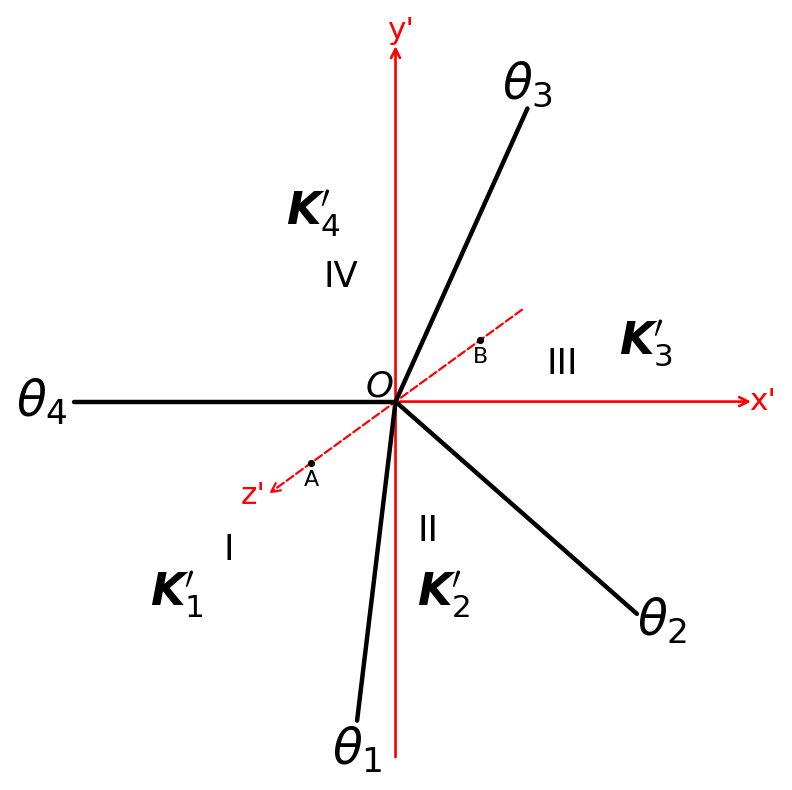

In [2]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(6, 6), dpi=160)

L = 1.0  # 坐标轴半长度
phi_3=1.1479716067981456
phi_1=-1.6907865554222983
phi_2=-0.7212640064250375
# 画十字轴（粗线）
ax.plot([-L, 0], [0, 0], color="black", lw=2, solid_capstyle="round")
ax.plot([np.cos(phi_3), 0], [np.sin(phi_3), 0], color="black", lw=2, solid_capstyle="round")
ax.plot([np.cos(phi_1), 0], [np.sin(phi_1), 0], color="black", lw=2, solid_capstyle="round")
ax.plot([np.cos(phi_2), 0], [np.sin(phi_2), 0], color="black", lw=2, solid_capstyle="round")
# 设置画布范围与比例
ax.set_xlim(-1.15, 1.15)
ax.set_ylim(-1.15, 1.15)
ax.set_aspect("equal", adjustable="box")
#ax.axis("off")

# 虚线坐标轴（带箭头）
arrow_kw = dict(arrowstyle="->", lw=1.2, linestyle="-", color="r")
arrow_kw1 = dict(arrowstyle="->", lw=1.0, linestyle="--", color="r")
ax.annotate("", xy=( 1.12, 0), xytext=(0, 0), arrowprops=arrow_kw, zorder=0)  # x轴
ax.annotate("", xy=(0,  1.12), xytext=(0, -1.12), arrowprops=arrow_kw, zorder=0)  # y轴

# 可选：轴标签
ax.text(1.10, -0.025, "x'", color="red", fontsize=14)
ax.text(-0.025, 1.13, "y'", color="red", fontsize=14)

theta_z = -4*np.pi/5
r = 0.5
ax.annotate("", xy=(r*np.cos(theta_z), r*np.sin(theta_z)),
            xytext=(-r*np.cos(theta_z), -r*np.sin(theta_z)), arrowprops=arrow_kw1, zorder=0)

# 可选：轴标签
ax.text(r*np.cos(theta_z)*1.00, r*np.sin(theta_z)*1.00+0.05, "z'",
        color="red", fontsize=14, ha="right", va="top")

# 不要外框/刻度（别用 ax.axis("off")）
for s in ax.spines.values():
    s.set_visible(False)
ax.set_xticks([])
ax.set_yticks([])


# 端点的 φ 标注（位置尽量贴近原图）
ax.text(np.cos(phi_3),  np.sin(phi_3), r"$\theta_3$", ha="center", va="bottom", fontsize=22)
ax.text(-1.02, 0.00, r"$\theta_4$", ha="right",  va="center", fontsize=22)
ax.text(np.cos(phi_1), np.sin(phi_1)-0.01, r"$\theta_1$", ha="center", va="top",    fontsize=22)
ax.text(np.cos(phi_2),  np.sin(phi_2)-0.02, r"$\theta_2$", ha="left",   va="center", fontsize=22)

# 象限里的 k 标注（按你图中相对位置摆放）
ax.text(0.52,  0.12, 'III', ha="center", va="center", fontsize=16)
ax.text(0.78,  0.18, r'$\boldsymbol{K}^{\prime}_3$', ha="center", va="center", fontsize=20)
ax.text(-0.17, 0.39, 'IV', ha="center", va="center", fontsize=16)
ax.text(-0.255,  0.585, r'$\boldsymbol{K}^{\prime}_4$', ha="center", va="center", fontsize=20)
ax.text(-0.52,-0.46, 'I', ha="center", va="center", fontsize=16)
ax.text(0.15,  -0.6, r'$\boldsymbol{K}^{\prime}_2$', ha="center", va="center", fontsize=20)
ax.text(-0.68,  -0.6, r'$\boldsymbol{K}^{\prime}_1$', ha="center", va="center", fontsize=20)
ax.text(0.1, -0.4, 'II', ha="center", va="center", fontsize=16)
ax.text(r*np.cos(theta_z)*0.65,r*np.sin(theta_z)*0.65-0.02,'A',ha="center", va="top", fontsize=10)
ax.text(-r*np.cos(theta_z)*0.65,-r*np.sin(theta_z)*0.65-0.02,'B',ha="center", va="top", fontsize=10)
# 原点附近的 0（原图里略偏下方）
ax.text(-0.05, 0.05, r"$O$", ha="center", va="center", fontsize=16)
ax.scatter(r*np.cos(theta_z)*0.65,r*np.sin(theta_z)*0.65, c='k', s=5)
ax.scatter(-r*np.cos(theta_z)*0.65,-r*np.sin(theta_z)*0.65, c='k', s=5)
plt.show()
